# The Spin Lab

Companion notebook to the blog post
[**The Apparatus and the Arrow**](https://jen1995.github.io/posts/the-apparatus-and-the-arrow/).

The post described a laboratory: one electron, one black-box apparatus
with an **arrow** and a **window**, and three experiments whose outcomes
quietly broke the classical picture of measurement. This notebook is that
laboratory, simulated — you can orient the arrow wherever you like, fire
as many measurements as you have patience for, and watch the statistics
converge.

One honest warning. The `Apparatus` class below necessarily *contains the
answer key*: the rule that decides when the window shows $+1$, which the
next posts of this act will slowly derive. You can treat the class as the
post treats the box — closed, played with only through its buttons — or
you can read its twenty lines and meet the rule ahead of schedule. Your
choice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# the blog's house palette
INK, SEC, GREY, FAINT = "#0b0b0b", "#52514e", "#8a8983", "#c9c8c2"
BLUE, ORANGE, VIOLET, AQUA = "#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "font.size": 10,
})

rng = np.random.default_rng(2026)


def direction(theta_deg, phi_deg=0.0):
    # a unit vector at polar angle theta (from +z) and azimuth phi, degrees
    th, ph = np.deg2rad(theta_deg), np.deg2rad(phi_deg)
    return np.array([np.sin(th) * np.cos(ph),
                     np.sin(th) * np.sin(ph),
                     np.cos(th)])


UP, DOWN, RIGHT = direction(0), direction(180), direction(90)

## The apparatus

Two buttons, exactly as in the post: `orient(arrow)` turns the whole box,
`measure(electron)` interacts with the electron and returns what the
window shows. A *fresh* electron is one nothing has measured yet — the
lab hands it to you with a spin direction drawn uniformly at random on
the sphere, and no record of it survives anywhere.

In [2]:
class Apparatus:
    def __init__(self, arrow=UP):
        self.arrow = np.asarray(arrow, dtype=float)

    def orient(self, arrow):
        self.arrow = np.asarray(arrow, dtype=float)
        return self

    def measure(self, electron):
        # ---- the answer key (posts QM-2..QM-4 will earn this rule) ----
        # probability of +1: cos^2 of HALF the angle between the
        # electron's prepared direction and the arrow
        cos_theta = np.clip(self.arrow @ electron.state, -1.0, 1.0)
        p_plus = (1.0 + cos_theta) / 2.0          # = cos^2(theta/2)
        outcome = +1 if rng.random() < p_plus else -1
        # measurement is a preparation: the electron leaves pointing
        # along the arrow (or against it), whatever it was before
        electron.state = outcome * self.arrow
        return outcome


class Electron:
    # a fresh electron: spin direction uniformly random on the sphere
    def __init__(self):
        v = rng.normal(size=3)
        self.state = v / np.linalg.norm(v)


def tape(outcomes):
    return "  ".join("+1" if o > 0 else "-1" for o in outcomes)

## Experiment one: repetition confirms

Take a fresh electron, point the arrow up, measure ten times. Run this
cell several times: the *first* value changes from run to run — the rest
never disagree with the first.

In [3]:
A = Apparatus(UP)
e = Electron()
print("arrow up, one fresh electron:  ", tape(A.measure(e) for _ in range(10)))

arrow up, one fresh electron:   -1  -1  -1  -1  -1  -1  -1  -1  -1  -1


## Experiment two: flipping negates

Prepare $+1$ with the arrow up (measure fresh electrons until one says
$+1$), then alternate the arrow between up and down. No randomness
anywhere — the answer just changes sign with the arrow.

In [4]:
A = Apparatus(UP)
e = Electron()
while A.measure(e) != +1:      # prepare: +1 along z
    e = Electron()

for _ in range(4):
    down = A.orient(DOWN).measure(e)
    up = A.orient(UP).measure(e)
    print(f"arrow down: {down:+d}    arrow up again: {up:+d}")

arrow down: -1    arrow up again: +1
arrow down: -1    arrow up again: +1
arrow down: -1    arrow up again: +1
arrow down: -1    arrow up again: +1


## Experiment three: turning the arrow

Prepare $+1$ along $\hat m = \hat z$, turn the apparatus to an angle
$\theta$, measure — and repeat the whole round many times. Single
outcomes stay $\pm 1$; their average traces the classical projection
$\langle \sigma \rangle = \cos\theta$. Turn the knobs: more rounds pin
the dots to the dashed curve.

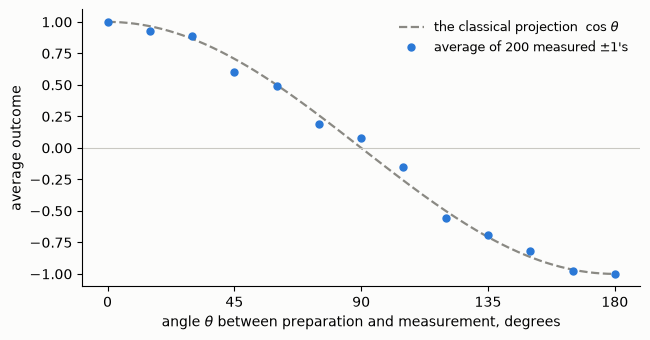

In [5]:
N_ROUNDS = 200          # rounds per angle -- crank it up

def prepared_electron(axis=UP):
    A, e = Apparatus(axis), Electron()
    while A.measure(e) != +1:
        e = Electron()
    return e

thetas = np.arange(0, 181, 15)
means = []
for th in thetas:
    A = Apparatus(direction(th))
    outcomes = [A.measure(prepared_electron()) for _ in range(N_ROUNDS)]
    means.append(np.mean(outcomes))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
grid = np.linspace(0, 180, 300)
ax.plot(grid, np.cos(np.deg2rad(grid)), ls="--", color=GREY, lw=1.6,
        label=r"the classical projection  $\cos\,\theta$")
ax.plot(thetas, means, "o", color=BLUE, ms=5,
        label=f"average of {N_ROUNDS} measured $\\pm 1$'s")
ax.axhline(0, color=FAINT, lw=0.8)
ax.set_xlabel(r"angle $\theta$ between preparation and measurement, degrees")
ax.set_ylabel("average outcome")
ax.set_xticks([0, 45, 90, 135, 180])
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## The cruelest twist: measuring along $x$ erases $z$

Prepare $+1$ along $z$, ask the $x$ question, then ask the $z$ question
again. Repetition no longer confirms — the certainty along $z$ is gone.

In [6]:
back_to_z = []
for _ in range(1000):
    e = prepared_electron(UP)          # certainly +1 along z
    A = Apparatus(RIGHT)
    A.measure(e)                       # ask the x question
    back_to_z.append(A.orient(UP).measure(e))   # ask z again

plus = sum(1 for o in back_to_z if o > 0)
print(f"prepared +1 along z, measured along x, then along z again:")
print(f"  +1 came back {plus} times out of {len(back_to_z)} -- a coin flip,")
print(f"  not the certain +1 the electron had before the x question")

prepared +1 along z, measured along x, then along z again:
  +1 came back 525 times out of 1000 -- a coin flip,
  not the certain +1 the electron had before the x question


## The teaser, verified: squared and halved

The post's last promise: the cosine of the experiments "will fall out,
squared and halved, on the surface of a sphere". The simulator lets us
peek at what that means numerically. Instead of averaging the outcomes,
count how *often* $+1$ appears at each angle. The frequency follows not
$\cos\theta$ but

$$P(+1) = \cos^2\!\left(\frac{\theta}{2}\right),$$

and the two curves say the same thing, since
$\langle\sigma\rangle = (+1)\,P(+1) + (-1)\,P(-1) = 2P(+1) - 1
= \cos\theta$. *Why* the probability is the cosine of half the angle,
squared, is the story of the Bloch sphere — a few posts from now.

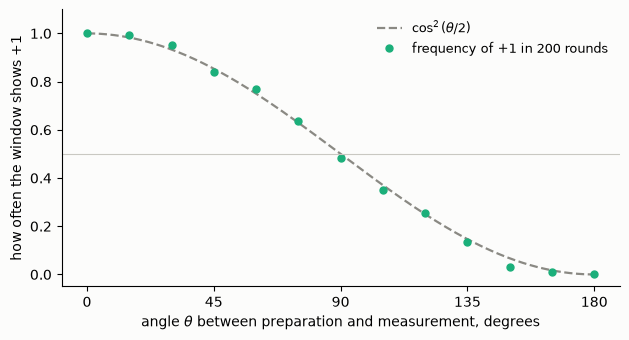

In [7]:
freqs = []
for th in thetas:
    A = Apparatus(direction(th))
    outcomes = [A.measure(prepared_electron()) for _ in range(N_ROUNDS)]
    freqs.append(np.mean([o > 0 for o in outcomes]))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(grid, np.cos(np.deg2rad(grid) / 2) ** 2, ls="--", color=GREY,
        lw=1.6, label=r"$\cos^2(\theta / 2)$")
ax.plot(thetas, freqs, "o", color=AQUA, ms=5,
        label=f"frequency of +1 in {N_ROUNDS} rounds")
ax.axhline(0.5, color=FAINT, lw=0.8)
ax.set_xlabel(r"angle $\theta$ between preparation and measurement, degrees")
ax.set_ylabel("how often the window shows +1")
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Things to try

- Set `N_ROUNDS = 10` and rerun experiment three: with few rounds the
  dots scatter far from the cosine — determinism really does live only
  in the average.
- Measure along $x$, then $y$, then $x$ again: *any* new axis erases the
  old certainty, not just the $z/x$ pair.
- Replace the fresh electron's random direction with a fixed secret one
  and see how quickly the statistics betray it.

Back to the road: [The Apparatus and the
Arrow](https://jen1995.github.io/posts/the-apparatus-and-the-arrow/).